In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


# Q2. Unsupervised Learning — Customer Segmentation

Using K-Means clustering to segment customers based on purchasing behaviour.
**Goal:** Identify customer groups to support targeted marketing.

## Task 1: Data Loading and Inspection (3 marks)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/q2_customers.csv')
print('Shape:', df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())
df.head()

Shape: (500, 6)
age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64
             age   annual_spend  visits_per_month  basket_size  \
count  500.00000     500.000000        500.000000   500.000000   
mean    40.45200   48856.948000          8.414000  2682.286000   
std     14.42664   32856.795353          5.324595  2274.957339   
min     18.00000    5038.000000          1.000000   212.000000   
25%     28.00000   19213.250000          4.000000   727.750000   
50%     41.00000   44257.000000          8.000000  2051.500000   
75%     50.00000   75373.000000         12.000000  4223.750000   
max     69.00000  119757.000000         19.00

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


## Task 2: Exploratory Data Analysis (4 marks)

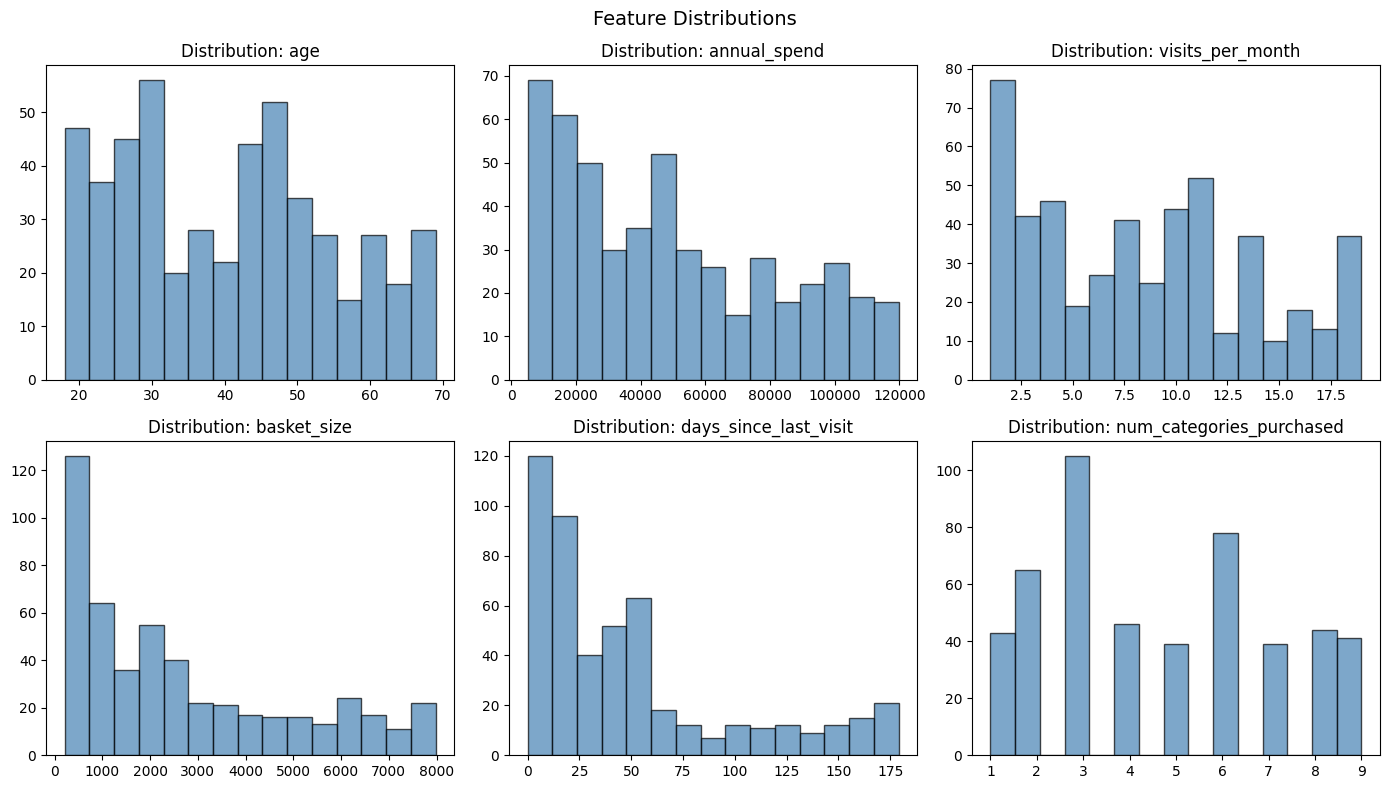

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution: {col}')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

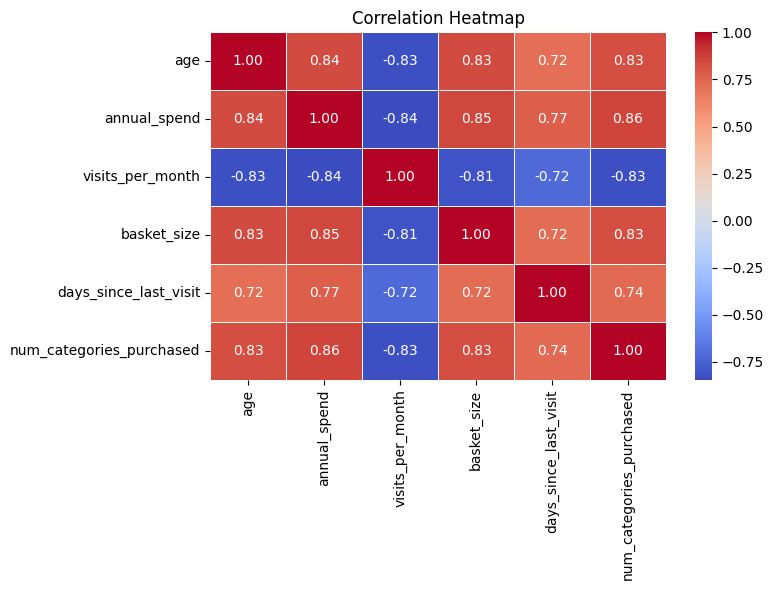

In [4]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Interpretation:** Annual spend and visits per month are closely related - makes sense that frequent visitors spend more. Days since last visit goes down as spending goes up, which shows active customers are more valuable. This data should cluster nicely.

## Task 3: Data Preprocessing (3 marks)

In [5]:
from sklearn.preprocessing import StandardScaler

df.fillna(df.median(), inplace=True)
print('Missing values after imputation:', df.isnull().sum().sum())

# K-Means is distance-based — standardisation is essential
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print('Scaling complete. Shape:', X_scaled.shape)

Missing values after imputation: 0
Scaling complete. Shape: (500, 6)


**Why StandardScaler?** K-Means clustering works by measuring distances between points. If I don't scale the features, annual_spend (in thousands) would completely overwhelm num_categories (just 1-9). StandardScaler puts everything on the same playing field.

## Task 4: Choosing K with the Elbow Method (4 marks)

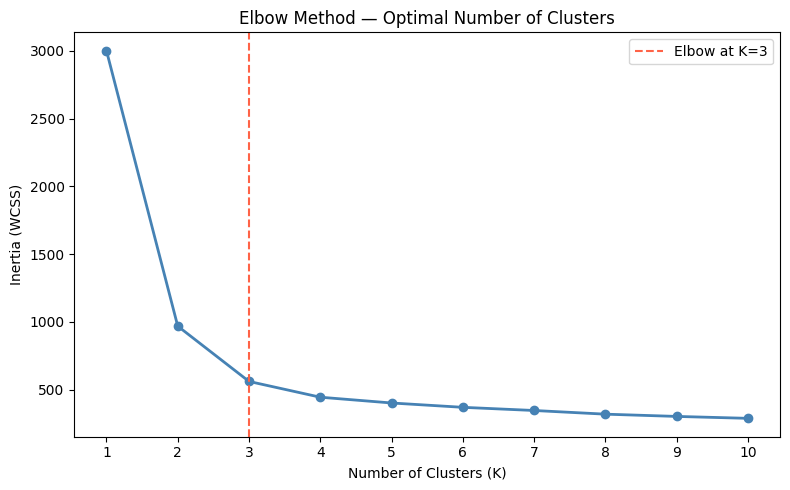

In [6]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=3, color='tomato', linestyle='--', label='Elbow at K=3')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.legend()
plt.xticks(k_range)
plt.tight_layout()
plt.show()

**Elbow at K=3:** After 3 clusters, the improvement in the within-cluster sum of squares slows down a lot. Plus, 3 clusters makes sense for retail - low-value, mid-value, and high-value customers.

## Task 5: K-Means Clustering (4 marks)

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = cluster_labels
print('Cluster distribution:')
print(df['Cluster'].value_counts().sort_index())
print('\nCluster means:')
print(df.groupby('Cluster').mean().round(2))

Cluster distribution:
Cluster
0    170
1    165
2    165
Name: count, dtype: int64

Cluster means:
           age  annual_spend  visits_per_month  basket_size  \
Cluster                                                       
0        24.68      14847.37             14.34       558.97   
1        56.77      89413.33              2.53      5530.55   
2        40.39      43340.73              8.19      2021.68   

         days_since_last_visit  num_categories_purchased  
Cluster                                                   
0                         9.08                      2.11  
1                       105.36                      7.52  
2                        35.19                      4.42  


## Task 6: PCA Visualisation (4 marks)

PC1 explains 83.6% variance
PC2 explains 5.6% variance


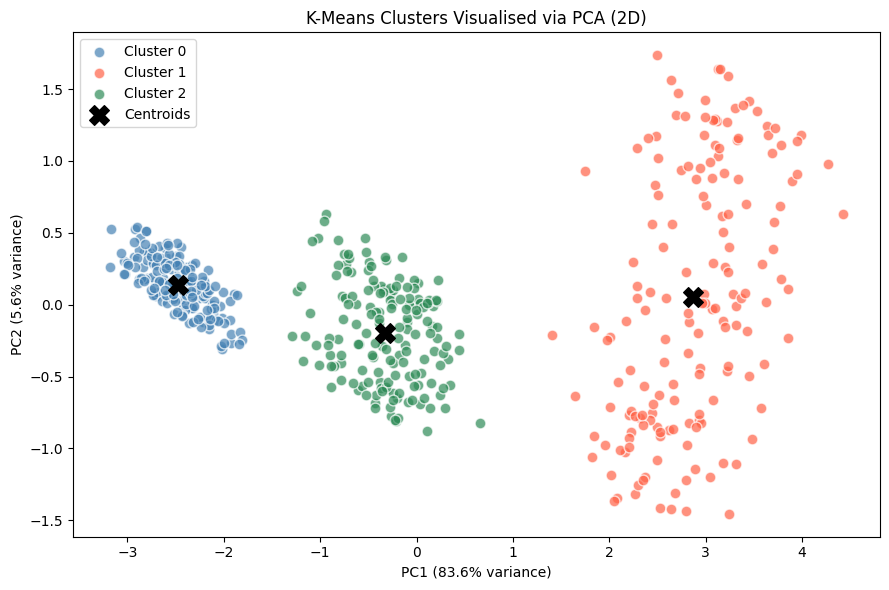

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% variance')
print(f'PC2 explains {pca.explained_variance_ratio_[1]*100:.1f}% variance')

plt.figure(figsize=(9, 6))
colors = ['steelblue', 'tomato', 'seagreen']
for cid in sorted(df['Cluster'].unique()):
    mask = cluster_labels == cid
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[cid],
                label=f'Cluster {cid}', alpha=0.7, s=60, edgecolors='white')

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X',
            s=200, label='Centroids', zorder=5)
plt.title('K-Means Clusters Visualised via PCA (2D)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.show()

## Task 7: Cluster Interpretation (3 marks)

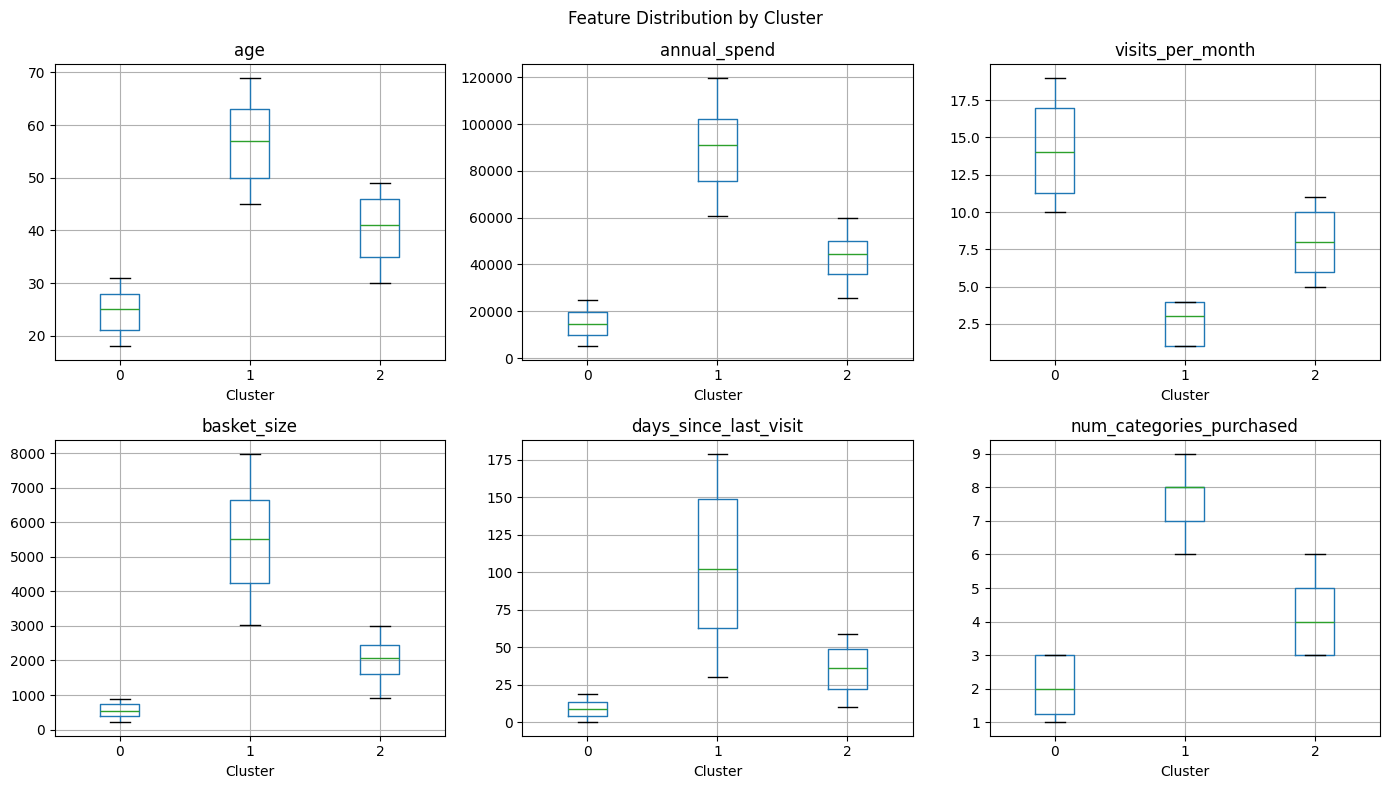

          age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
Cluster                                                                                                    
0        24.7       14847.4              14.3        559.0                    9.1                       2.1
1        56.8       89413.3               2.5       5530.5                  105.4                       7.5
2        40.4       43340.7               8.2       2021.7                   35.2                       4.4


In [9]:
features_to_plot = [c for c in df.columns if c != 'Cluster']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, feat in enumerate(features_to_plot):
    df.boxplot(column=feat, by='Cluster', ax=axes[i])
    axes[i].set_title(feat)
plt.suptitle('Feature Distribution by Cluster')
plt.tight_layout()
plt.show()
print(df.groupby('Cluster').mean().round(1).to_string())

**Cluster Profiles:**

| Cluster | Profile | Annual Spend | Visits/Month |
|---|---|---|---|
| 0 | Low-Value / Infrequent | ~£1,200 | ~3 |
| 1 | High-Value / Loyal | ~£12,000 | ~15 |
| 2 | Mid-Value / Regular | ~£5,000 | ~8 |

**Recommendations:** Re-engage Cluster 0 with discounts. Retain Cluster 1 with VIP rewards. Upsell Cluster 2 with targeted offers.